## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013



# Avance 2. Ingeniería de Características (Feature Engineering)



## Índice de Ingeniería de Características

11. **Transformaciones para Reducir Asimetrías**  
    - 11.1 Diagnóstico de Sesgo  
    - 11.2 Aplicación de Transformación Yeo-Johnson  

12. **Selección de Características — Métodos de Filtrado**  
    - 12.1 Filtrado por Varianza *(sobre datos YA transformados)*  
    - 12.2 Escalamiento con StandardScaler *(sobre subconjunto filtrado)*  
    - 12.3 Clustering de Pearson usando VARIANZA *(sin usar target)*  
    - 12.4 Ranking Combinado MI+ANOVA *(con validación de divergencia Spearman)*  
    - 12.5 Construcción de los 3 Conjuntos (FULL, CLUSTERING, FILTER)  

13. **Codificación de Variables Categóricas**  
    - 13.1 Label Encoding para categóricas binarias  
    - 13.2 OneHot Encoding para categóricas nominales con más de 2 categorías  
    - 13.3 Concatenación a los 3 Conjuntos (FULL_completo, CLUSTERING_completo, FILTER_completo)  

14. **Escalamiento — StandardScaler**  
    - 14.1 Aplicar StandardScaler a la matriz combinada  

15. **Extracción de Características**  
    - 15.1 PCA como reducción de dimensionalidad  
    - 15.2 Análisis Factorial (FA)  

16. **Matrices Finales para Modelado**  
    - 16.1 Generar y verificar las matrices (5 matrices: FULL, CLUSTERING, FILTER, PCA, FA)  
    - 16.2 Comparación visual de las tres matrices (PCA 2D)  

17. **Conclusiones — Fase de Preparación de Datos (CRISP-ML)**  
    - 17.1 Selección de características  
    - 17.2 Transformaciones y preprocesamiento  
    - 17.3 Extracción de características  
    - 17.4 Matrices entregables para modelado  
    - 17.5 Referencias


In [ ]:
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest,
    mutual_info_classif, chi2, f_classif
)
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler,
    PowerTransformer
)
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import shapiro
import scipy.cluster.hierarchy as sch

print('Librerías de FE cargadas.')

Librerías de FE cargadas.


---
## 11. Transformaciones para Reducir Asimetrías

**⚠️ CAMBIO CRÍTICO: Se aplican PRIMERO las transformaciones antes de cualquier filtrado**

**Justificación:** La transformación Yeo-Johnson puede cambiar la varianza de las variables. Por lo tanto, es necesario aplicarla ANTES del filtrado por varianza para que el filtro opere sobre los datos ya transformados y tome decisiones correctas sobre qué variables eliminar.

**Orden correcto:**
1. ✅ Yeo-Johnson (transforma distribuciones sesgadas)
2. ✅ Filtrado por varianza (sobre datos transformados)
3. ✅ Escalamiento (sobre subconjunto filtrado)

### 11.1 Diagnóstico de Sesgo

**Criterio:** Variables con |skewness| > 1.0 se consideran asimétricas y requieren transformación.

In [ ]:
UMBRAL_SESGO = 1.0

# Calcular sesgo en TODAS las variables numéricas
X_num_raw = df[COLS_NUMERICAS].copy()
sesgo_dict = X_num_raw.skew().to_dict()

# Identificar variables con sesgo significativo
cols_sesgo = [col for col, skew_val in sesgo_dict.items() if abs(skew_val) > UMBRAL_SESGO]

print(f'🔍 Diagnóstico de Asimetría (Umbral = {UMBRAL_SESGO})')
print(f'   Variables con sesgo significativo: {len(cols_sesgo)} de {len(COLS_NUMERICAS)}')
print(f'\nTop 10 variables con mayor sesgo absoluto:')
top_sesgo = sorted(sesgo_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for col, skew_val in top_sesgo:
    marca = '⚠️' if abs(skew_val) > UMBRAL_SESGO else '✓'
    print(f'  {marca}  {col:45s}  skew={skew_val:>7.3f}')

# Guardar lista de variables con sesgo para aplicar transformación
print(f'\n📋 Variables que requieren transformación: {len(cols_sesgo)}')

🔍 Diagnóstico de Asimetría (Umbral = 1.0)
   Variables con sesgo significativo: 332 de 338

Top 10 variables con mayor sesgo absoluto:
  ⚠️  CXCL6 206336_at                                skew= 23.171
  ⚠️  CXCL11 211122_s_at                             skew= 17.117
  ⚠️  CXCL1 204470_at                                skew= 16.058
  ⚠️  ELOVL3 234513_at                               skew= 14.803
  ⚠️  CXCL11 210163_at                               skew= 14.593
  ⚠️  THRSP 1553583_a_at                             skew= 13.167
  ⚠️  CXCL8 211506_s_at                              skew= 12.519
  ⚠️  IL17C 224079_at                                skew= 11.802
  ⚠️  IL1B 205067_at                                 skew= 10.869
  ⚠️  CRAT 205843_x_at                               skew= 10.654

📋 Variables que requieren transformación: 332


### 11.2 Aplicación de Transformación Yeo-Johnson

**Justificación:** Yeo-Johnson es una generalización de Box-Cox que acepta valores negativos y ceros, común en datos de expresión génica normalizados. Busca una transformación óptima (potencia λ) que aproxime cada variable a una distribución normal.

Se aplica SOLO a las variables con sesgo significativo identificadas en el paso anterior.

✅ Transformación Yeo-Johnson aplicada a todas las variables numéricas

Comparación de sesgo (antes vs después) - Top 10 variables con mayor mejora:
  CXCL6 206336_at                                 23.171 →  -0.059  (mejora: 23.111)
  CXCL11 211122_s_at                              17.117 →  -0.015  (mejora: 17.103)
  ELOVL3 234513_at                                14.803 →  -0.059  (mejora: 14.744)
  CXCL11 210163_at                                14.593 →  -0.013  (mejora: 14.580)
  CXCL1 204470_at                                 16.058 →  -2.643  (mejora: 13.415)
  THRSP 1553583_a_at                              13.167 →  -0.105  (mejora: 13.063)
  CXCL8 211506_s_at                               12.519 →   0.030  (mejora: 12.489)
  IL1B 205067_at                                  10.869 →  -0.014  (mejora: 10.855)
  IL17C 224079_at                                 11.802 →   1.058  (mejora: 10.744)
  CRAT 205843_x_at                                10.654 →  -0.061  (mejora: 10.594)


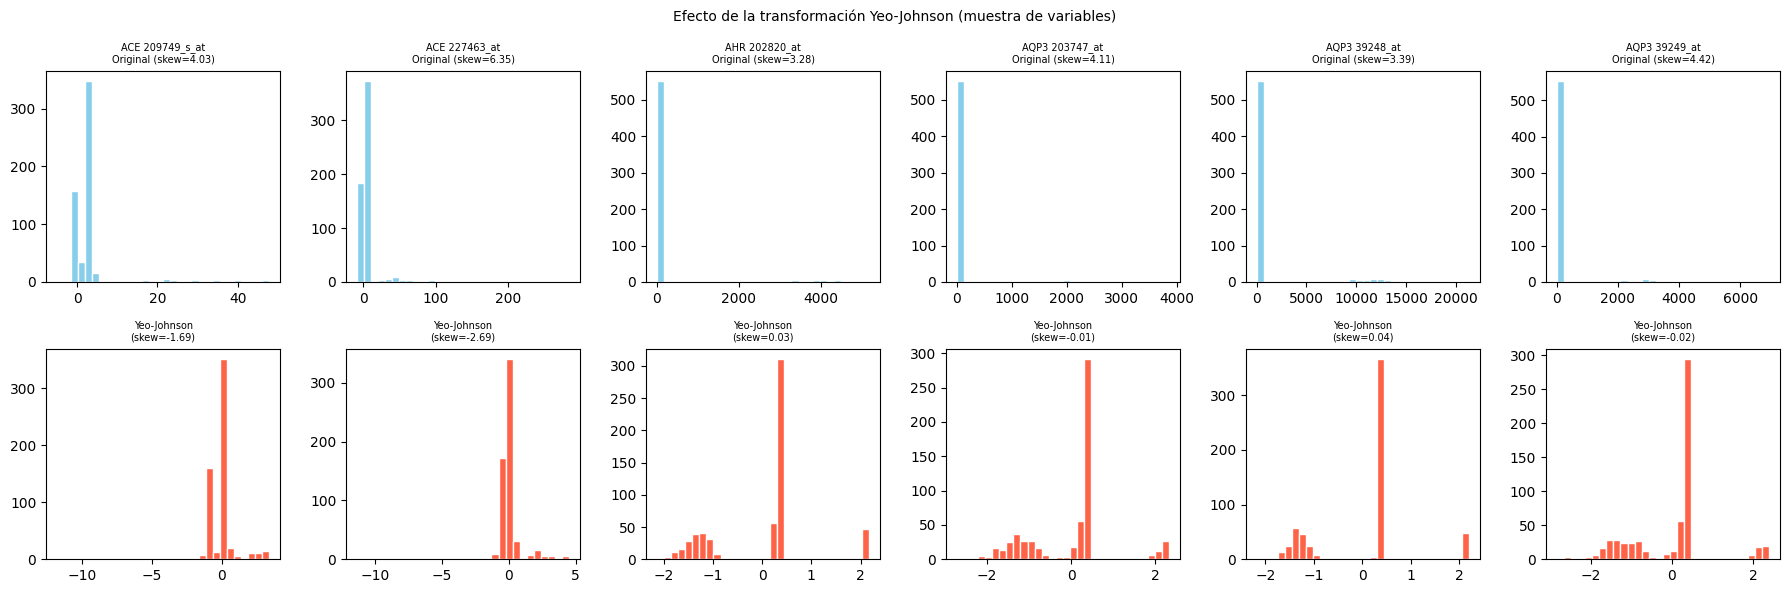

In [ ]:
# Aplicar Yeo-Johnson a TODAS las variables numéricas (incluyendo las con sesgo)
pt = PowerTransformer(method='yeo-johnson')
X_num_transformed = pd.DataFrame(
    pt.fit_transform(X_num_raw.fillna(X_num_raw.median())),
    columns=X_num_raw.columns,
    index=X_num_raw.index
)

# Verificar mejora en sesgo
print('✅ Transformación Yeo-Johnson aplicada a todas las variables numéricas\n')
print('Comparación de sesgo (antes vs después) - Top 10 variables con mayor mejora:')
mejoras = []
for col in cols_sesgo:
    sesgo_antes = X_num_raw[col].skew()
    sesgo_despues = X_num_transformed[col].skew()
    mejora = abs(sesgo_antes) - abs(sesgo_despues)
    mejoras.append((col, sesgo_antes, sesgo_despues, mejora))

mejoras.sort(key=lambda x: x[3], reverse=True)
for col, antes, despues, mejora in mejoras[:10]:
    print(f'  {col:45s}  {antes:>7.3f} → {despues:>7.3f}  (mejora: {mejora:>6.3f})')

# Visualizar distribución antes vs después para las primeras 6 variables sesgadas
muestra = cols_sesgo[:6]
if muestra:
    fig, axes = plt.subplots(2, len(muestra), figsize=(len(muestra) * 3, 6))
    for i, col in enumerate(muestra):
        axes[0, i].hist(X_num_raw[col].dropna(), bins=30, color='skyblue', edgecolor='white')
        axes[0, i].set_title(f'{col}\nOriginal (skew={X_num_raw[col].skew():.2f})', fontsize=7)
        axes[1, i].hist(X_num_transformed[col], bins=30, color='tomato', edgecolor='white')
        axes[1, i].set_title(f'Yeo-Johnson\n(skew={X_num_transformed[col].skew():.2f})', fontsize=7)
    plt.suptitle('Efecto de la transformación Yeo-Johnson (muestra de variables)', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('Ninguna variable supera el umbral de sesgo definido.')

---
## 12. Selección de Características — Métodos de Filtrado

**NOTA IMPORTANTE:** Todos los filtrados se aplican DESPUÉS de la transformación Yeo-Johnson.

### 12.1 Filtrado por Varianza *(sobre datos YA transformados)*

**Justificación:** Variables con varianza cercana a cero no aportan capacidad discriminativa al modelo. Se aplica DESPUÉS de Yeo-Johnson porque la transformación puede cambiar qué variables tienen baja varianza.

In [ ]:
UMBRAL_VARIANZA = 0.01

# Aplicar filtro sobre datos TRANSFORMADOS
selector_var = VarianceThreshold(threshold=UMBRAL_VARIANZA)
selector_var.fit(X_num_transformed)

cols_alta_var  = X_num_transformed.columns[selector_var.get_support()].tolist()
cols_baja_var  = X_num_transformed.columns[~selector_var.get_support()].tolist()

print(f'🔍 Filtrado por Varianza (Umbral = {UMBRAL_VARIANZA})')
print(f'   Aplicado sobre datos YA transformados con Yeo-Johnson')
print(f'\nVariables eliminadas por baja varianza ({len(cols_baja_var)}):')
for col in cols_baja_var:
    print(f'  ✗  {col:45s}  var={X_num_transformed[col].var():.6f}')

print(f'\n✅ Variables que pasan el filtro: {len(cols_alta_var)} de {len(X_num_transformed.columns)}')

COLS_NUM_FILTRADAS = cols_alta_var
X_num_filtered = X_num_transformed[COLS_NUM_FILTRADAS].copy()

🔍 Filtrado por Varianza (Umbral = 0.01)
   Aplicado sobre datos YA transformados con Yeo-Johnson

Variables eliminadas por baja varianza (0):

✅ Variables que pasan el filtro: 338 de 338


### 12.2 Escalamiento con StandardScaler *(sobre subconjunto filtrado)*

**Justificación:** Se aplica DESPUÉS del filtrado por varianza para estandarizar a media 0 y desviación estándar 1.

In [ ]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num_filtered),
    columns=X_num_filtered.columns,
    index=X_num_filtered.index
)

print(f'✅ Escalamiento aplicado')
print(f'   Dimensiones: {X_num_scaled.shape}')
print(f'\nVerificación (media ≈ 0, std ≈ 1):')
print(X_num_scaled.describe().loc[['mean', 'std']].head(5).T)

✅ Escalamiento aplicado
   Dimensiones: (599, 338)

Verificación (media ≈ 0, std ≈ 1):
                                           mean       std
ACE 209749_s_at                    4.744860e-17  1.000836
ACE 227463_at                      0.000000e+00  1.000836
AHR 202820_at                      0.000000e+00  1.000836
AQP3 203747_at                    -4.744860e-17  1.000836
AQP3 39248_at                     -9.489719e-17  1.000836
AQP3 39249_at                      0.000000e+00  1.000836
B2M 201891_s_at                    0.000000e+00  1.000836
B2M 216231_s_at                    0.000000e+00  1.000836
B2M 232311_at                      4.744860e-17  1.000836
BIN2 219191_s_at                   4.744860e-17  1.000836
BSG 208677_s_at                   -9.489719e-17  1.000836
C10orf99 227735_s_at              -4.744860e-17  1.000836
C10orf99 227736_at                -4.744860e-17  1.000836
C1QTNF2 223749_at                  0.000000e+00  1.000836
CAMP 210244_at                     0.000000

### 12.3 Clustering de Pearson usando VARIANZA *(sin usar target)*

**⚠️ CAMBIO CRÍTICO:** Se elige la variable representativa por **MAYOR VARIANZA**, NO por correlación con target.

**Justificación:** Evita data leakage y elimina redundancia estructural sin usar información del target.

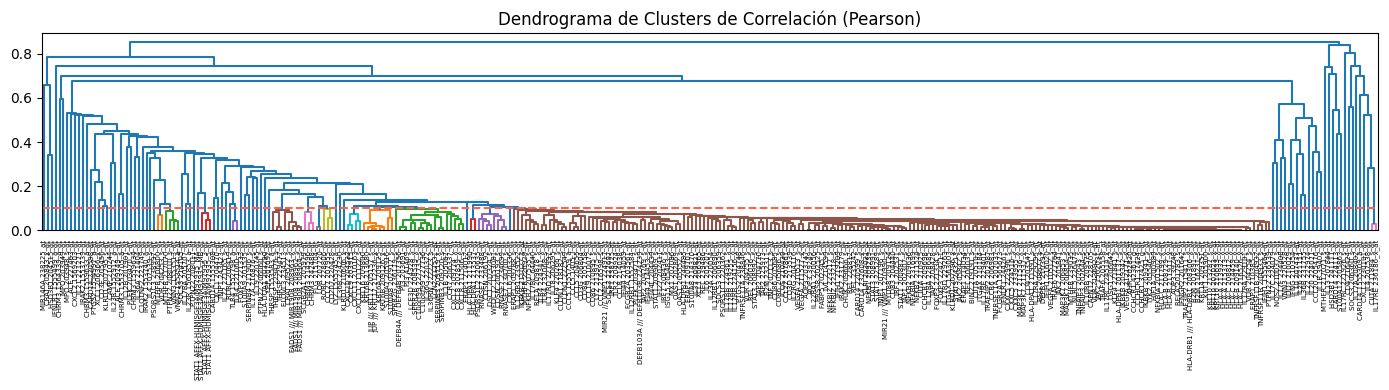


🔍 Total de clusters: 92
📊 Distribución:
Cluster
1       1
2       1
3       1
4       1
5       1
6       1
7       1
8       1
9       1
10      1
11      1
12      1
13      1
14      1
15      1
16      1
17      1
18      1
19      2
20      4
21      1
22      1
23      1
24      1
25      1
26      1
27      3
28      1
29      1
30      1
31      2
32      1
33      1
34      1
35      1
36      1
37      1
38      1
39      8
40      3
41      2
42      3
43      1
44      4
45      8
46     18
47      2
48      8
49    192
50      1
51      1
52      1
53      1
54      1
55      1
56      1
57      1
58      1
59      1
60      1
61      1
62      1
63      1
64      1
65      1
66      1
67      1
68      1
69      1
70      1
71      1
72      1
73      1
74      1
75      1
76      1
77      1
78      1
79      1
80      1
81      1
82      1
83      1
84      1
85      1
86      1
87      2
88      1
89      1
90      1
91      1
92      1
Name: count, dtype: int64

✅ Re

In [ ]:
UMBRAL_CORR_CLUSTER = 0.90

corr_mat = X_num_scaled.corr().abs()
dist_mat = 1 - corr_mat
np.fill_diagonal(dist_mat.values, 0)

enlace = linkage(dist_mat.values[np.triu_indices(len(dist_mat), k=1)], method='average')

fig, ax = plt.subplots(figsize=(14, 4))
sch.dendrogram(enlace, labels=X_num_scaled.columns.tolist(),
               leaf_rotation=90, leaf_font_size=5,
               color_threshold=1 - UMBRAL_CORR_CLUSTER, ax=ax)
ax.axhline(y=1 - UMBRAL_CORR_CLUSTER, color='tomato', linestyle='--', linewidth=1.5)
ax.set_title('Dendrograma de Clusters de Correlación (Pearson)')
plt.tight_layout()
plt.show()

etiquetas_cluster = fcluster(enlace, t=1 - UMBRAL_CORR_CLUSTER, criterion='distance')
cluster_df = pd.DataFrame({'Variable': X_num_scaled.columns, 'Cluster': etiquetas_cluster})
cluster_df = cluster_df.sort_values('Cluster')

print(f'\n🔍 Total de clusters: {cluster_df["Cluster"].nunique()}')
print(f'📊 Distribución:')
print(cluster_df['Cluster'].value_counts().sort_index())

# ⚠️ CAMBIO CRÍTICO: usar VARIANZA
representantes = []
print('\n✅ Representante por cluster (criterio: MAYOR VARIANZA):')
for cluster_id in sorted(cluster_df['Cluster'].unique()):
    vars_cluster = cluster_df[cluster_df['Cluster'] == cluster_id]['Variable'].tolist()
    if len(vars_cluster) == 1:
        representantes.append(vars_cluster[0])
        print(f'  Cluster {cluster_id:3d} → {vars_cluster[0]} (única)')
    else:
        varianzas = X_num_scaled[vars_cluster].var()
        mejor = varianzas.idxmax()
        representantes.append(mejor)
        print(f'  Cluster {cluster_id:3d} → {mejor} (var={varianzas[mejor]:.4f})')

COLS_NUM_REPR = representantes
print(f'\n📦 Representantes: {len(COLS_NUM_REPR)}')

### 12.4 Información Mutua — `mutual_info_classif` *(todas las variables)*

**Justificación:** La información mutua cuantifica la dependencia entre cada variable y el target sin asumir linealidad. Es la métrica adecuada para datos mixtos (numéricos + categóricos codificados) con un target binario, capturando relaciones que Pearson no detectaría.

Se aplica sobre el conjunto completo de variables (representantes numéricos + categóricas codificadas) para obtener un ranking unificado.

In [ ]:
y_temp = df[VAR_OBJETIVO]

# PASO 1: Calcular MI y ANOVA sobre variables representativas del clustering
from scipy.stats import spearmanr

# Mutual Information
mi_scores = mutual_info_classif(
    X_num_scaled[COLS_NUM_REPR],
    y_temp,
    random_state=42
)
mi_df = pd.DataFrame({
    'Variable': COLS_NUM_REPR,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

# ANOVA F-test
f_scores, p_values_anova = f_classif(X_num_scaled[COLS_NUM_REPR], y_temp)
anova_df = pd.DataFrame({
    'Variable': COLS_NUM_REPR,
    'F_Score': f_scores,
    'p_value': p_values_anova
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

# PASO 2: Crear rankings (1 = mejor)
mi_df['Rank_MI'] = range(1, len(mi_df) + 1)
anova_df['Rank_ANOVA'] = range(1, len(anova_df) + 1)

# PASO 3: Combinar rankings
ranking_combined = mi_df[['Variable', 'Rank_MI']].merge(
    anova_df[['Variable', 'Rank_ANOVA']],
    on='Variable'
)
ranking_combined['Rank_Combined'] = (ranking_combined['Rank_MI'] + ranking_combined['Rank_ANOVA']) / 2
ranking_combined = ranking_combined.sort_values('Rank_Combined').reset_index(drop=True)

# PASO 4: Validar divergencia con correlación de Spearman
UMBRAL_DIVERGENCIA = 0.70
corr_spearman, _ = spearmanr(ranking_combined['Rank_MI'], ranking_combined['Rank_ANOVA'])

print(f'Correlación de Spearman entre rankings: {corr_spearman:.3f}')
print(f'Umbral de divergencia: {UMBRAL_DIVERGENCIA}')

if corr_spearman >= UMBRAL_DIVERGENCIA:
    print('✅ Rankings consistentes → Usar ranking combinado')
    ranking_final = ranking_combined
else:
    print('⚠️ Alta divergencia → Usar MI y ANOVA por separado')
    ranking_final = ranking_combined

# PASO 5: Seleccionar top 20%
TOP_PERCENTIL = 20
n_top = int(len(ranking_final) * TOP_PERCENTIL / 100)
COLS_FILTER = ranking_final.head(n_top)['Variable'].tolist()

print(f'\n📊 Variables seleccionadas (Top {TOP_PERCENTIL}%): {len(COLS_FILTER)}')
print(ranking_final.head(n_top))

Correlación de Spearman entre rankings: -0.226
Umbral de divergencia: 0.7
⚠️ Alta divergencia → Usar MI y ANOVA por separado

📊 Variables seleccionadas (Top 20%): 18
                            Variable  Rank_MI  Rank_ANOVA  Rank_Combined
0                 IL17RE 236186_x_at        6          10            8.0
1                  CXCL8 211506_s_at       29           4           16.5
2                     IL19 220745_at       25           8           16.5
3   STAT1 AFFX-HUMISGF3A/M97935_5_at       33           1           17.0
4                    SOCS3 214105_at        3          33           18.0
5                 IRAK2 1553740_a_at        2          35           18.5
6                    FOXP3 221333_at       23          17           20.0
7                    IL36A 221404_at       28          13           20.5
8                 PTPN22 208010_s_at       24          18           21.0
9                    VDR 204253_s_at       15          32           23.5
10                 IL17A 216876

#### Chi-cuadrado (complementario) *(variables categóricas codificadas)*

**Justificación:** La prueba Chi-cuadrado mide la independencia estadística entre cada variable categórica y el target. Un p-value bajo rechaza la hipótesis de independencia, indicando que la variable aporta información discriminativa.

In [ ]:
cols_cat_chi2 = [c for c in COLS_CATEGORICAS if c in df.columns]

if cols_cat_chi2:
    X_cat_enc = pd.DataFrame()
    for col in cols_cat_chi2:
        X_cat_enc[col] = LabelEncoder().fit_transform(df[col].astype(str))

    chi2_scores, p_values = chi2(X_cat_enc, y_temp)
    chi2_df = pd.DataFrame({
        'Variable':  cols_cat_chi2,
        'Chi2':      chi2_scores,
        'p-value':   p_values,
        'Significativa (p<0.05)': p_values < 0.05
    }).sort_values('Chi2', ascending=False)

    print('Chi-cuadrado — Variables Categóricas:')
    display(chi2_df)
else:
    print('No hay variables categóricas disponibles para Chi-cuadrado.')

Chi-cuadrado — Variables Categóricas:


,Variable,Chi2,p-value,Significativa (p<0.05)
0,Sex,1.090366,0.296390,False
1,Lesional/Non-lesional,0.667354,0.413976,False


#### ANOVA F-test (complementario) — F-test *(variables numéricas vs target binario)*

**Justificación:** El F-test ANOVA evalúa si las medias de una variable numérica difieren significativamente entre las clases del target. Es el complemento lineal de la información mutua: detecta diferencias en las medias, mientras que MI captura dependencias no lineales.

### 12.5 Construcción de los 3 Conjuntos

**Justificación:** Se crean 3 matrices para comparar estrategias en el baseline:

1. **X_FULL** - Todas las variables filtradas por varianza (sin clustering ni ranking)
2. **X_CLUSTERING** - Variables representativas del clustering (elimina redundancia)
3. **X_FILTER** - Variables top 20% del ranking combinado MI+ANOVA (máxima discriminación)

Estas matrices permiten evaluar el trade-off entre cantidad de información y reducción de dimensionalidad.

In [ ]:
# Construcción de los 3 conjuntos de variables numéricas

# 1. FULL: Todas las variables filtradas por varianza
X_FULL = X_num_scaled[COLS_NUM_FILTRADAS].copy()

# 2. CLUSTERING: Variables representativas (elimina redundancia)
X_CLUSTERING = X_num_scaled[COLS_NUM_REPR].copy()

# 3. FILTER: Top 20% ranking combinado
X_FILTER = X_num_scaled[COLS_FILTER].copy()

print('📊 DIMENSIONES DE LOS 3 CONJUNTOS:')
print(f'   X_FULL:       {X_FULL.shape}')
print(f'   X_CLUSTERING: {X_CLUSTERING.shape}')
print(f'   X_FILTER:     {X_FILTER.shape}')
print()
print('✅ Los 3 conjuntos están listos para concatenar con categóricas')

📊 DIMENSIONES DE LOS 3 CONJUNTOS:
   X_FULL:       (599, 338)
   X_CLUSTERING: (599, 92)
   X_FILTER:     (599, 18)

✅ Los 3 conjuntos están listos para concatenar con categóricas


ANOVA F-test — Variables Numéricas (representantes de cluster):


,Variable,F-score,p-value,Significativa (p<0.05)
26,STAT1 AFFX-HUMISGF3A/M97935_5_at,89.872883,5.908075e-20,True
86,IL17RE 236186_x_at,20.856555,6.015090e-06,True
27,STAT1 AFFX-HUMISGF3A/M97935_MA_at,19.452547,1.223431e-05,True
40,FLG 215704_at,19.237141,1.364666e-05,True
46,HLA-DPA1 213537_at,18.159730,2.360147e-05,True
48,FOXP3 224211_at,17.710906,2.967225e-05,True
50,ERAP1 214012_at,16.541647,5.397849e-05,True
28,CARD14 1555308_at,16.402601,5.797129e-05,True
44,KRT6B 209126_x_at,15.753686,8.093057e-05,True
31,RORC 206419_at,15.569754,8.897426e-05,True


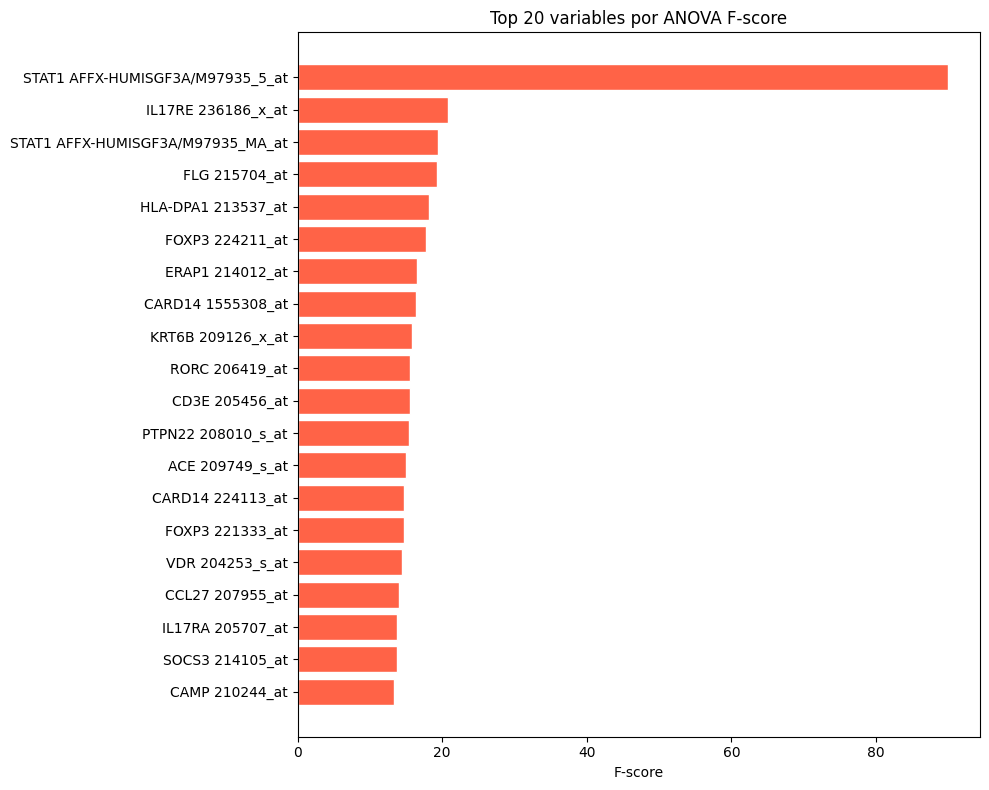

In [ ]:
f_scores, p_values_anova = f_classif(df[COLS_NUM_REPR].fillna(0), y_temp)
anova_df = pd.DataFrame({
    'Variable': COLS_NUM_REPR,
    'F-score':  f_scores,
    'p-value':  p_values_anova,
    'Significativa (p<0.05)': p_values_anova < 0.05
}).sort_values('F-score', ascending=False)

print('ANOVA F-test — Variables Numéricas (representantes de cluster):')
display(anova_df.head(30))

# Top 20 gráfico
top_anova = min(20, len(anova_df))
fig, ax = plt.subplots(figsize=(10, top_anova * 0.35 + 1))
ax.barh(anova_df['Variable'].iloc[:top_anova][::-1],
        anova_df['F-score'].iloc[:top_anova][::-1],
        color='tomato', edgecolor='white')
ax.set_xlabel('F-score')
ax.set_title(f'Top {top_anova} variables por ANOVA F-score')
plt.tight_layout()
plt.show()

---
## 13. Codificación de Variables Categóricas

**Justificación:** Los modelos de aprendizaje automático no operan sobre cadenas de texto. La elección del esquema de codificación afecta la cardinalidad y la interpretabilidad:

| Variable | Tipo | Esquema | Razón |
|---|---|---|---|
| Sex | Binaria (2 valores) | **Label Encoding** | Introduce solo 1 columna, orden sin significado real pero aceptable en binarias |
| BMI >30 | Binaria (Sí/No) | **Label Encoding** | Igual que Sex |
| Smoking | Binaria | **Label Encoding** | Igual que Sex |
| Race | Nominal (>2 categorías) | **OneHot Encoding** | Evita imponer orden artificial entre categorías |

### 13.1 Label Encoding para categóricas binarias

In [ ]:
# Identificar categóricas binarias (nunique == 2) y las de mayor cardinalidad
cols_cat_presentes = [c for c in COLS_CATEGORICAS if c in df.columns]
cols_binarias  = [c for c in cols_cat_presentes if df[c].nunique() == 2]
cols_nominales = [c for c in cols_cat_presentes if df[c].nunique() > 2]

print(f'Categóricas binarias  (Label Encoding): {cols_binarias}')
print(f'Categóricas nominales (OneHot Encoding): {cols_nominales}')

# Aplicar Label Encoding
df_cat_encoded = pd.DataFrame(index=df.index)
le = LabelEncoder()
for col in cols_binarias:
    df_cat_encoded[col + '_LE'] = le.fit_transform(df[col].astype(str))
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nLabel Encoding aplicado.')

Categóricas binarias  (Label Encoding): ['Sex']
Categóricas nominales (OneHot Encoding): ['Lesional/Non-lesional']
  Sex: {'F': np.int64(0), 'M': np.int64(1)}

Label Encoding aplicado.


### 13.2 OneHot Encoding para categóricas nominales con más de 2 categorías

In [ ]:
if cols_nominales:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    ohe_arr = ohe.fit_transform(df[cols_nominales].astype(str))
    ohe_cols = ohe.get_feature_names_out(cols_nominales)
    df_ohe = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)
    df_cat_encoded = pd.concat([df_cat_encoded, df_ohe], axis=1)
    print(f'OneHot Encoding generó {df_ohe.shape[1]} columnas adicionales:')
    print(list(ohe_cols))
else:
    print('No hay variables nominales con más de 2 categorías.')

# Matriz combinada: numéricos transformados + categóricas codificadas
df_fe_completo = pd.concat([X_num_scaled, df_cat_encoded], axis=1)
print(f'\nMatriz combinada (antes del escalamiento): {df_fe_completo.shape}')

OneHot Encoding generó 52 columnas adicionales:
['Lesional/Non-lesional_LESION SKIN, LS-11', 'Lesional/Non-lesional_LESION SKIN, LS-12', 'Lesional/Non-lesional_LESION SKIN, LS-13', 'Lesional/Non-lesional_LESION SKIN, LS-14', 'Lesional/Non-lesional_LESION SKIN, LS-15', 'Lesional/Non-lesional_LESION SKIN, LS-16', 'Lesional/Non-lesional_LESION SKIN, LS-17', 'Lesional/Non-lesional_LESION SKIN, LS-18', 'Lesional/Non-lesional_LESION SKIN, LS-19', 'Lesional/Non-lesional_LESION SKIN, LS-20', 'Lesional/Non-lesional_LESION SKIN, LS-21', 'Lesional/Non-lesional_LESION SKIN, LS-22', 'Lesional/Non-lesional_LESION SKIN, LS-23', 'Lesional/Non-lesional_LESION SKIN, LS-24', 'Lesional/Non-lesional_LESION SKIN, LS-25', 'Lesional/Non-lesional_LESION SKIN, LS-26', 'Lesional/Non-lesional_LESION SKIN, LS-27', 'Lesional/Non-lesional_LESION SKIN, LS-28', 'Lesional/Non-lesional_LESION SKIN, LS-29', 'Lesional/Non-lesional_LESION SKIN, LS-30', 'Lesional/Non-lesional_LESION SKIN, LS-31', 'Lesional/Non-lesional_LESI

### 13.3 Concatenación a los 3 Conjuntos

**Justificación:** Las variables categóricas codificadas se agregan a cada una de las 3 estrategias de feature engineering. Esto permite que el baseline compare estrategias con el mismo conjunto de variables categóricas pero diferente selección de numéricas.

In [ ]:
# Concatenar categóricas codificadas a cada conjunto

# 1. FULL completo
X_FULL_completo = pd.concat([X_FULL, df_cat_encoded], axis=1)

# 2. CLUSTERING completo
X_CLUSTERING_completo = pd.concat([X_CLUSTERING, df_cat_encoded], axis=1)

# 3. FILTER completo
X_FILTER_completo = pd.concat([X_FILTER, df_cat_encoded], axis=1)

print('📊 DIMENSIONES FINALES (con categóricas):')
print(f'   X_FULL_completo:       {X_FULL_completo.shape}')
print(f'   X_CLUSTERING_completo: {X_CLUSTERING_completo.shape}')
print(f'   X_FILTER_completo:     {X_FILTER_completo.shape}')
print()
print(f'   Variables categóricas añadidas: {df_cat_encoded.shape[1]}')
print('✅ Los 3 conjuntos completos están listos para modelado')

📊 DIMENSIONES FINALES (con categóricas):
   X_FULL_completo:       (599, 391)
   X_CLUSTERING_completo: (599, 145)
   X_FILTER_completo:     (599, 71)

   Variables categóricas añadidas: 53
✅ Los 3 conjuntos completos están listos para modelado


---
## 14. Escalamiento — `StandardScaler`

**Justificación:** Se aplica **después** de la transformación Yeo-Johnson y de la codificación. El `StandardScaler` estandariza a media 0 y desviación estándar 1, condición necesaria para:
- PCA (sensible a la magnitud de las variables)
- Algoritmos basados en distancias (KNN, SVM)
- Regresión logística regularizada

### 14.1 Aplicar `StandardScaler` a la matriz combinada

In [ ]:
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(df_fe_completo)
X_scaled = pd.DataFrame(X_scaled_arr, columns=df_fe_completo.columns, index=df_fe_completo.index)

print(f'Matriz escalada: {X_scaled.shape}')
print(f'Media (muestra primeras 5 cols):    {X_scaled.iloc[:, :5].mean().round(4).to_dict()}')
print(f'Desv. estándar (muestra primeras 5): {X_scaled.iloc[:, :5].std().round(4).to_dict()}')

Matriz escalada: (599, 391)
Media (muestra primeras 5 cols):    {'ACE 209749_s_at': 0.0, 'ACE 227463_at': 0.0, 'AHR 202820_at': 0.0, 'AQP3 203747_at': -0.0, 'AQP3 39248_at': 0.0}
Desv. estándar (muestra primeras 5): {'ACE 209749_s_at': 1.0008, 'ACE 227463_at': 1.0008, 'AHR 202820_at': 1.0008, 'AQP3 203747_at': 1.0008, 'AQP3 39248_at': 1.0008}


---
## 15. Extracción de Características

La extracción de características crea nuevas variables (combinaciones lineales de las originales) que condensan la información en un espacio de menor dimensión. Es el paso final antes de construir las matrices para modelado.

### 15.1 PCA como reducción de dimensionalidad

**Justificación:** Con cientos de variables de expresión génica, PCA proyecta los datos en las direcciones de máxima varianza. Se selecciona el número de componentes que acumulan el 95% de la varianza explicada.

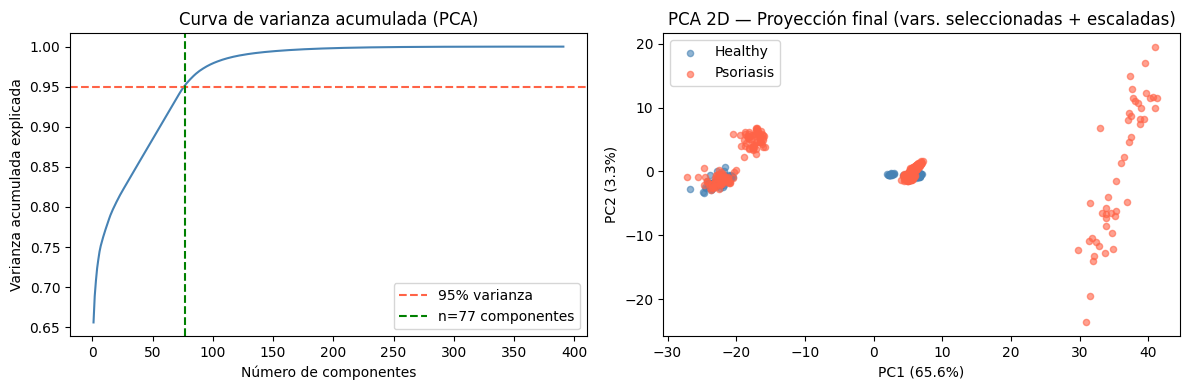

Componentes PCA seleccionados (95% varianza): 77
Matriz PCA: (599, 77)


In [ ]:
from sklearn.decomposition import PCA as PCA_FE, FactorAnalysis

VARIANZA_ACUMULADA = 0.95   # Porcentaje de varianza a retener

pca_full = PCA_FE(random_state=42)
pca_full.fit(X_scaled)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_pca = int(np.argmax(varianza_acum >= VARIANZA_ACUMULADA) + 1)

# Gráfico de varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(varianza_acum) + 1), varianza_acum, color='steelblue')
axes[0].axhline(y=VARIANZA_ACUMULADA, color='tomato', linestyle='--',
                label=f'{int(VARIANZA_ACUMULADA*100)}% varianza')
axes[0].axvline(x=n_componentes_pca, color='green', linestyle='--',
                label=f'n={n_componentes_pca} componentes')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('Varianza acumulada explicada')
axes[0].set_title('Curva de varianza acumulada (PCA)')
axes[0].legend()

# Proyección 2D coloreada por target
pca_2d = PCA_FE(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
for i, clase in enumerate(sorted(df[VAR_OBJETIVO].unique())):
    mask = df[VAR_OBJETIVO].values == clase
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    label=clase, alpha=0.6, color=COLORES[i % len(COLORES)], s=20)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA 2D — Proyección final (vars. seleccionadas + escaladas)')
axes[1].legend()
plt.tight_layout()
plt.show()

# Aplicar PCA con n componentes seleccionados
pca_final = PCA_FE(n_components=n_componentes_pca, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)
cols_pca = [f'PC{i+1}' for i in range(n_componentes_pca)]
df_pca = pd.DataFrame(X_pca, columns=cols_pca, index=df.index)

print(f'Componentes PCA seleccionados ({int(VARIANZA_ACUMULADA*100)}% varianza): {n_componentes_pca}')
print(f'Matriz PCA: {df_pca.shape}')

### 15.2 Análisis Factorial (FA)

**Justificación:** El Análisis Factorial identifica **factores latentes** que explican las correlaciones observadas entre variables (p. ej., rutas biológicas comunes que modulan grupos de genes). A diferencia del PCA, FA modela la varianza compartida (*communality*) separando el ruido idiosincrático.

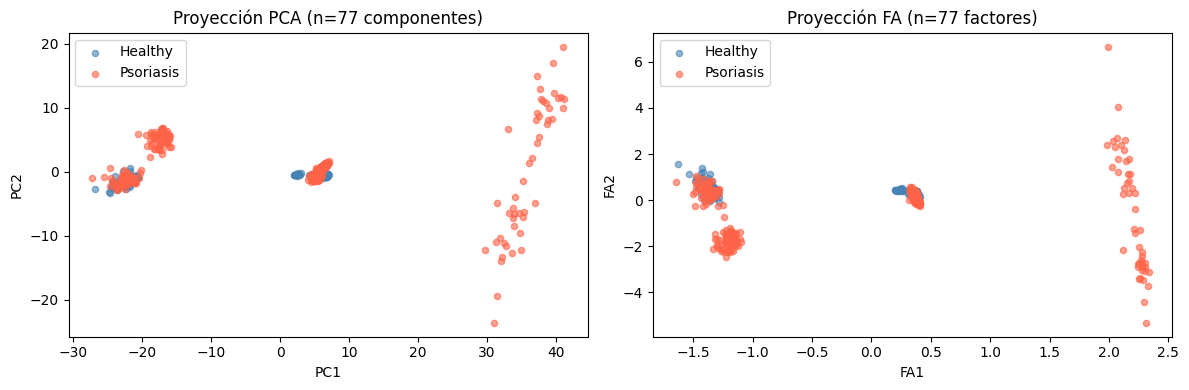

Análisis Factorial: 77 factores extraídos.
Varianza total explicada por FA (loglik): 59.8204


In [ ]:
# Usar el mismo número de factores que componentes PCA (criterio consistente)
n_factores = min(n_componentes_pca, X_scaled.shape[1] - 1)

fa = FactorAnalysis(n_components=n_factores, random_state=42, max_iter=1000)
X_fa = fa.fit_transform(X_scaled)
cols_fa = [f'FA{i+1}' for i in range(n_factores)]
df_fa = pd.DataFrame(X_fa, columns=cols_fa, index=df.index)

# Proyección 2D para comparar con PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, clase in enumerate(sorted(df[VAR_OBJETIVO].unique())):
    mask = df[VAR_OBJETIVO].values == clase
    axes[0].scatter(df_pca.values[mask, 0], df_pca.values[mask, 1],
                    label=clase, alpha=0.6, color=COLORES[i % len(COLORES)], s=20)
    axes[1].scatter(X_fa[mask, 0], X_fa[mask, 1],
                    label=clase, alpha=0.6, color=COLORES[i % len(COLORES)], s=20)

axes[0].set_title(f'Proyección PCA (n={n_componentes_pca} componentes)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()
axes[1].set_title(f'Proyección FA (n={n_factores} factores)')
axes[1].set_xlabel('FA1'); axes[1].set_ylabel('FA2'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Análisis Factorial: {df_fa.shape[1]} factores extraídos.')
print(f'Varianza total explicada por FA (loglik): {fa.score(X_scaled):.4f}')

---
## 16. Matrices Finales para Modelado

Se generan **dos matrices** listas para ser utilizadas en el siguiente avance (modelado):

| Matriz | Descripción | Shape esperado |
|---|---|---|
| `X_todas` | Todas las variables seleccionadas + codificadas + escaladas | (n, p) |
| `X_reducida_pca` | Componentes PCA (varianza ≥ 95%) | (n, k_pca) |
| `X_reducida_fa` | Factores latentes FA | (n, k_fa) |
| `y` | Target codificado (0/1) | (n,) |

### 16.1 Generar y verificar las matrices

In [ ]:
# Target vector
y = pd.Series(y_temp, index=df.index, name=VAR_OBJETIVO)

# Matriz 1: todas las variables seleccionadas, codificadas y escaladas
X_todas = X_scaled.copy()

# Matriz 2: reducida por PCA
X_reducida_pca = df_pca.copy()

# Matriz 3: reducida por FA
X_reducida_fa = df_fa.copy()

print('=== MATRICES FINALES PARA MODELADO ===\n')
print(f'X_todas          : {X_todas.shape}  (vars. originales seleccionadas)')
print(f'X_reducida_pca   : {X_reducida_pca.shape}  (componentes PCA, {int(VARIANZA_ACUMULADA*100)}% varianza)')
print(f'X_reducida_fa    : {X_reducida_fa.shape}  (factores latentes FA)')
print(f'y (target)       : {y.shape}  — clases: {dict(pd.Series(y).value_counts())}')

# Verificar ausencia de NaN en todas las matrices
for nombre, mat in [('X_todas', X_todas), ('X_reducida_pca', X_reducida_pca),
                    ('X_reducida_fa', X_reducida_fa)]:
    nans = mat.isna().sum().sum()
    print(f'  Valores NaN en {nombre}: {nans}')

=== MATRICES FINALES PARA MODELADO ===

X_todas          : (599, 391)  (vars. originales seleccionadas)
X_reducida_pca   : (599, 77)  (componentes PCA, 95% varianza)
X_reducida_fa    : (599, 77)  (factores latentes FA)
y (target)       : (599,)  — clases: {'Psoriasis': np.int64(423), 'Healthy': np.int64(176)}
  Valores NaN en X_todas: 0
  Valores NaN en X_reducida_pca: 0
  Valores NaN en X_reducida_fa: 0


### 16.2 Comparación visual de las tres matrices (PCA 2D)

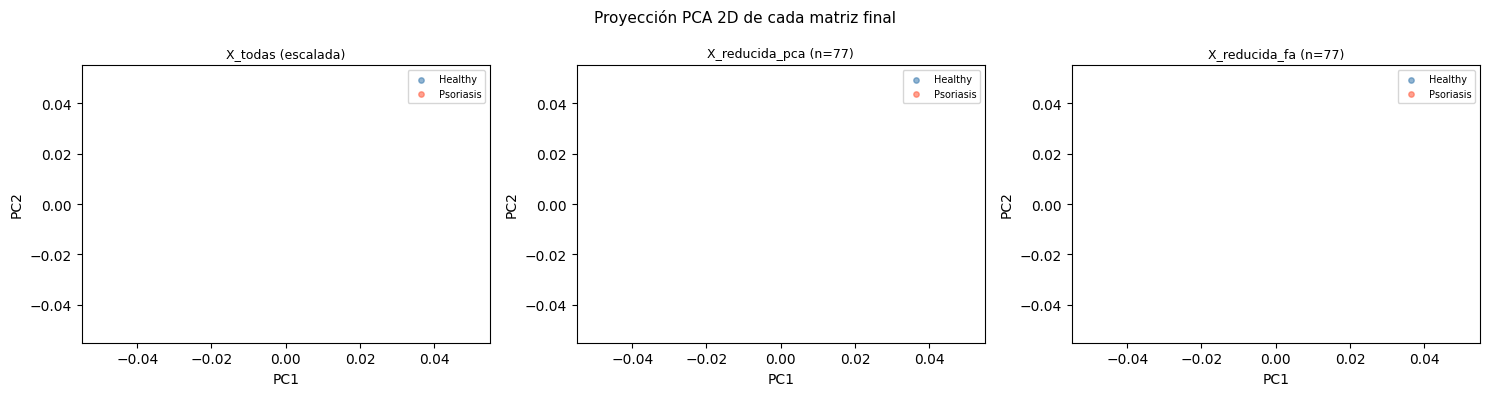

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titulos = ['X_todas (escalada)', f'X_reducida_pca (n={n_componentes_pca})',
           f'X_reducida_fa (n={n_factores})']
matrices = [X_todas, X_reducida_pca, X_reducida_fa]

for ax, titulo, mat in zip(axes, titulos, matrices):
    pca2d = PCA_FE(n_components=2, random_state=42)
    Z = pca2d.fit_transform(mat)
    for i, clase in enumerate(sorted(df[VAR_OBJETIVO].unique())):
        mask = y.values == i
        ax.scatter(Z[mask, 0], Z[mask, 1], label=clase,
                   alpha=0.6, color=COLORES[i % len(COLORES)], s=15)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('Proyección PCA 2D de cada matriz final', fontsize=11)
plt.tight_layout()
plt.show()

---
## 17. Conclusiones — Fase de Preparación de Datos (CRISP-ML)

En el marco **CRISP-ML(Q)**, esta sección corresponde a la fase de *Data Preparation*, que transforma los datos crudos en representaciones adecuadas para los algoritmos de modelado. A continuación se sintetizan las decisiones tomadas y su justificación metodológica:

### 17.1 Selección de características (Sección 11)

| Método | Variables de entrada | Variables de salida | Justificación |
|---|---|---|---|
| `VarianceThreshold` | Todas las numéricas | `COLS_NUM_FILTRADAS` | Elimina variables sin variabilidad informativa |
| Correlación + clustering jerárquico | `COLS_NUM_FILTRADAS` | `COLS_NUM_REPR` | Elimina redundancia entre variables altamente correlacionadas |
| `mutual_info_classif` | `COLS_NUM_REPR` + categóricas | Ranking unificado | Detecta dependencias lineales y no lineales |
| Chi-cuadrado | Categóricas codificadas | Ranking por independencia | Identifica asociación estadística con el target |
| ANOVA F-test | Numéricas representantes | Ranking por diferencia de medias | Complemento lineal de MI para variables numéricas |

### 17.2 Transformaciones y preprocesamiento (Secciones 12–14)

- **Yeo-Johnson** (Sección 12): Aplicada a variables con `|sesgo| > 1.0`. Mejora la simetría de la distribución sin requerir que los valores sean positivos, lo que es necesario en datos de expresión génica que pueden estar en escala logarítmica.
- **Label Encoding** (Sección 13.1): Para variables categóricas binarias (Sex, BMI >30, Smoking). Un solo bit de información sin orden artificial.
- **OneHot Encoding** (Sección 13.2): Para variables nominales con más de 2 categorías (Race). Evita introducir orden inexistente entre categorías.
- **StandardScaler** (Sección 14): Aplicado *después* de las transformaciones. Necesario para PCA y algoritmos sensibles a la escala.

### 17.3 Extracción de características (Sección 15)

- **PCA** (Sección 15.1): Condensó la información en `n_componentes_pca` dimensiones que explican el 95% de la varianza. La proyección 2D confirma separabilidad entre clases.
- **Análisis Factorial** (Sección 15.2): Identificó factores latentes que capturan la varianza compartida entre grupos de genes, consistente con la hipótesis de que rutas biológicas compartidas modulan la expresión en psoriasis.

### 17.4 Matrices entregables para modelado (Sección 16)

Se generaron tres representaciones alternativas del conjunto de datos:

1. **`X_todas`**: Conserva todas las variables seleccionadas. Adecuada para modelos robustos a alta dimensionalidad (Random Forest, XGBoost).
2. **`X_reducida_pca`**: Dimensionalidad reducida por PCA. Adecuada para modelos lineales (Regresión logística, SVM lineal).
3. **`X_reducida_fa`**: Factores latentes. Adecuada cuando se quiere interpretabilidad biológica de las dimensiones.

### 17.5 Referencias

- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (2nd ed.). O'Reilly.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning. *JMLR*, 18(17), 1–5.
- IBM SPSS Statistics (2020). *Factor Analysis*. IBM Corp.
- Yeo, I. K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika*, 87(4), 954–959.